In [1]:
import numpy as np
import pandas as pd
import pickle as pkl
# !pip install rpy2 # need to install this
from src.run_app import *
from src.prepare_gam import *
from matplotlib import pyplot as plt
from src.utils import *

# Sample code for generating GAM Rashomon Sets

header dimension 142
lamb0:0.001, lamb2:0.5, acc:0.6709135659475894, auc:0.728105294647142, supp_size:15
pair before removing {'age': [22.0, 27.0, 32.0, 33.0, 36.0], 'juvenile_crimes': [0.0], 'priors_count': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]}
k, v age [22.0, 27.0, 32.0, 33.0, 36.0, 96]
k, v juvenile_crimes [0.0, 20]
k, v priors_count [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 38]
pair after removing {'age': [22.0, 27.0, 32.0, 33.0, 36.0, 96], 'juvenile_crimes': [0.0, 20], 'priors_count': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 38]}
v_count: [0, 6, 2, 9]
[ 0  6  8 17]
age 0 0
age 1 1
age 2 2
age 3 3
age 4 4
age 5 5
juvenile_crimes 0 6
juvenile_crimes 1 7
priors_count 0 8
priors_count 1 9
priors_count 2 10
priors_count 3 11
priors_count 4 12
priors_count 5 13
priors_count 6 14
priors_count 7 15
priors_count 8 16
True
True
True
(18,) hi
(18,) hi2
(6907, 18) (18,) (6907, 18) (18,)
objective: 1.0675942570197012 objective in LR 1.0675942570197012
m:1.01, log objective:1.067594257019701

<Figure size 550x400 with 0 Axes>

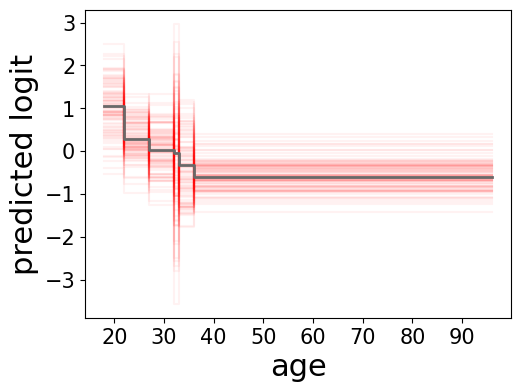

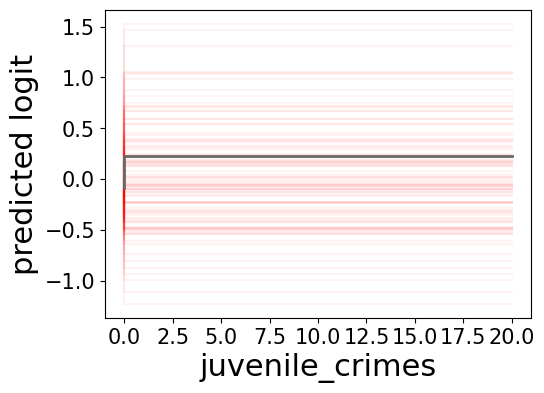

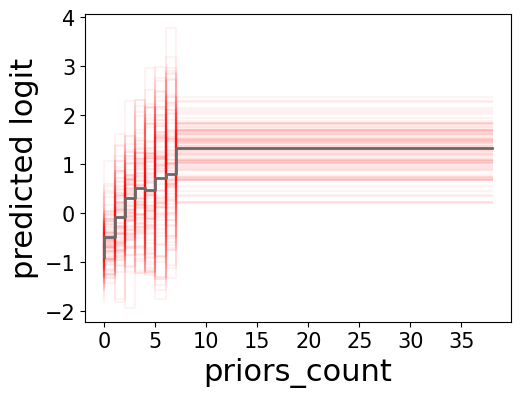

In [ ]:
dname = "compas"
l0 = 0.001
l2 = 0.5
m = 1.01
betas_fastSparse = prepare_sparse_gam(dname, l0, l2, m)

filepath = "{}_{}_{}_{}.p".format(dname, l0, l2, m)

w_samples = get_models_from_rset(
    filepath, n_samples=100, plot_shape=True, sample_from_surface=False)

In [3]:
data = pd.read_csv("datasets/{}.csv".format(dname))
y = data.iloc[:, -1].values
for i in range(len(w_samples)): # samples from the Rashomon set
    w0 = w_samples[i, :]
    X_fastsparse = pkl.load(open(betas_fastSparse, 'rb'))['X']
    logits = X_fastsparse@w0
    y_pred = np.exp(logits)/(1+np.exp(logits))
    y_pred[y_pred > 0.5] = 1
    y_pred[y_pred <= 0.5] = -1
    print((y != y_pred).mean(), len(
        pkl.load(open(betas_fastSparse, 'rb'))['header_new'])) 
    # only accuracy (which can vary more than the Rashomon set amount because remember the Rashomon set is wrt the regularized objective)

0.5857825394527291 18
0.6768495728970609 18
0.7905023888808456 18
0.7318662226726509 18
0.7291153901838714 18
0.7011727233241639 18
0.7499638048356739 18
0.7899232662516288 18
0.6645432170262053 18
0.8529028521789489 18
0.8180107137686405 18
0.654119009700304 18
0.5914289850875923 18
0.8460981612856522 18
0.8711452149992761 18
0.7211524540321413 18
0.8566671492688577 18
0.8268423338641957 18
0.8035326480382221 18
0.7199942087737078 18
0.7364992037063848 18
0.5844795135369915 18
0.7881858983639786 18
0.7797886202403359 18
0.7188359635152743 18
0.6487621253800492 18
0.6788765020993195 18
0.7356305197625598 18
0.7986101056898798 18
0.702041407267989 18
0.7315766613580426 18
0.7692196322571304 18
0.7564789344143622 18
0.7351961777906472 18
0.7115969306500651 18
0.9467207181120603 18
0.7199942087737078 18
0.7499638048356739 18
0.7928188793977125 18
0.6581728681048212 18
0.937889098016505 18
0.7153612277399739 18
0.8052700159258723 18
0.6377587954249312 18
0.716229911683799 18
0.744896481830

bias [0, 1]
age [18, 22.0, 27.0, 32.0, 33.0, 36.0, 96.0]
juvenile_crimes [0, 0.0, 20.0]
priors_count [0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 38.0]


<Figure size 550x400 with 0 Axes>

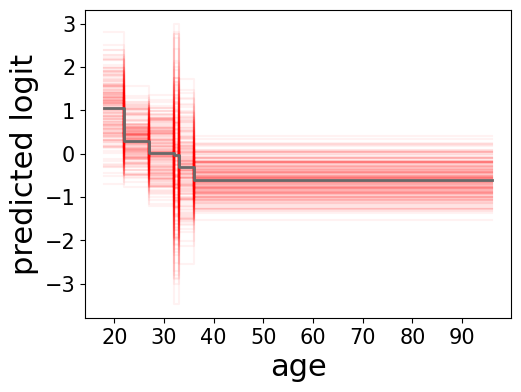

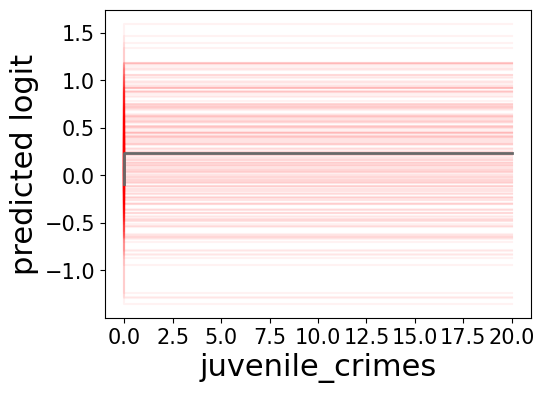

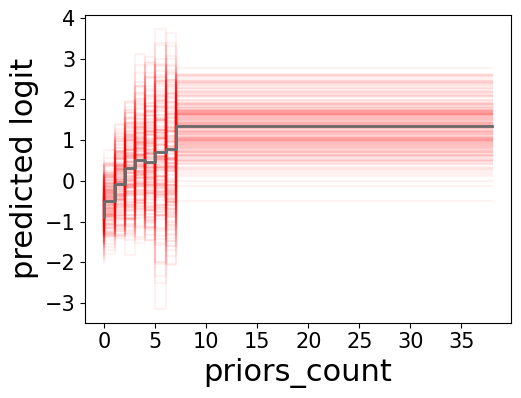

In [4]:
sample_from_surface = True
rset = RSetGAMs(filepath)
w_samples = rset.sample_in_ellipsoid(
    rset.H, rset.w_orig, n_samples=200, sample_from_surface=sample_from_surface)
count = 0
for key, values in rset.xlabel.items():
    print(key, values)
    plt.figure(figsize=(5.5, 4))
    l = count
    r = count + len(values)-1
    count += len(values)-1

    if key == "bias":
        continue

    for i, w_new in enumerate(w_samples):
        plt.step(values, np.hstack(
            (w_new[l], w_new[l:r])), c="red", alpha=0.05)

    plt.step(values, np.hstack(
        (rset.w_orig[l], rset.w_orig[l:r])), c="dimgray", linewidth=2)

    plt.xlabel(key, fontsize=22)
    plt.ylabel("predicted logit", fontsize=22)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)

# Comparing single support set vs multiple support set GAM Rashomon sets

## FastSparse for Single Support Set GAM

header dimension 142
lamb0:0.001, lamb2:0.5, acc:0.6709135659475894, auc:0.728105294647142, supp_size:15
pair before removing {'age': [22.0, 27.0, 32.0, 33.0, 36.0], 'juvenile_crimes': [0.0], 'priors_count': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]}
k, v age [22.0, 27.0, 32.0, 33.0, 36.0, 96]
k, v juvenile_crimes [0.0, 20]
k, v priors_count [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 38]
pair after removing {'age': [22.0, 27.0, 32.0, 33.0, 36.0, 96], 'juvenile_crimes': [0.0, 20], 'priors_count': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 38]}
v_count: [0, 6, 2, 9]
[ 0  6  8 17]
age 0 0
age 1 1
age 2 2
age 3 3
age 4 4
age 5 5
juvenile_crimes 0 6
juvenile_crimes 1 7
priors_count 0 8
priors_count 1 9
priors_count 2 10
priors_count 3 11
priors_count 4 12
priors_count 5 13
priors_count 6 14
priors_count 7 15
priors_count 8 16
True
True
True
(18,) hi
(18,) hi2
(6907, 18) (18,) (6907, 18) (18,)
objective: 1.0675942570197012 objective in LR 1.0675942570197012
m:1.01, log objective:1.067594257019701

<Figure size 550x400 with 0 Axes>

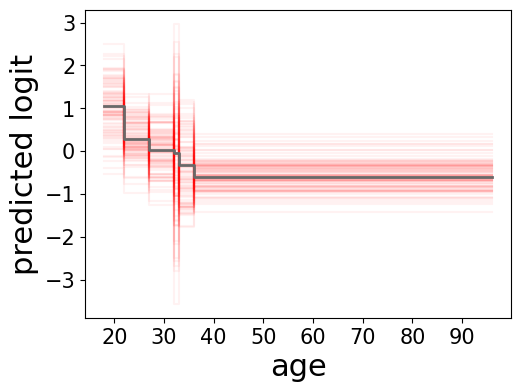

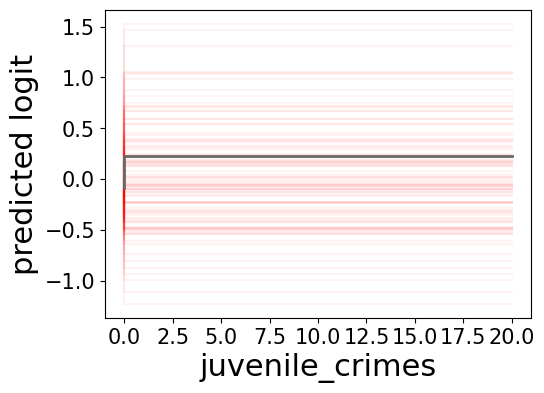

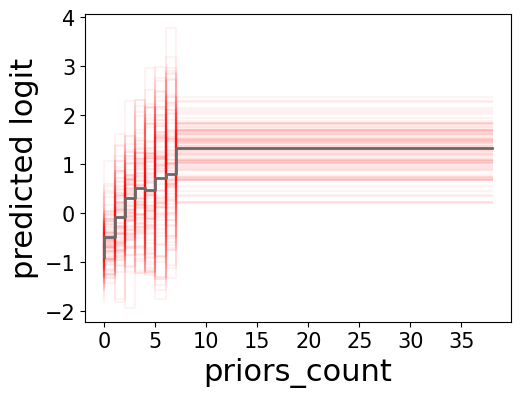

In [ ]:
from src.utils import one_hot_encoding
import numpy as np
import pandas as pd
import pickle
# !pip install rpy2
from src.run_app import *
from src.prepare_gam import *
from matplotlib import pyplot as plt
import pickle as pkl
from src.utils import *

dname = "compas"
l0 = 0.001
l2 = 0.5
m = 1.01
betas_fastSparse = prepare_sparse_gam('compas', lamb0=l0, lamb2=l2, multiplier=1.01)
filepath = "{}_{}_{}_{}.p".format(dname, l0, l2, m)

w_samples = get_models_from_rset(filepath, n_samples=100, plot_shape=True, sample_from_surface=False)

In [26]:
import numpy as np
import pandas as pd
import pickle
# !pip install rpy2
from src.run_app import *
from src.prepare_gam import *
from matplotlib import pyplot as plt
import pickle as pkl
from src import utils

dataset_name = 'compas'
path = 'datasets/{}.csv'.format(
    dataset_name)
dataset = pd.read_csv(path)
dataset.iloc[:, -1][dataset.iloc[:, -1] == 0] = -1
X, y = dataset.iloc[:, :-1], dataset.iloc[:, -1]
X_one_hot, count = one_hot_encoding(X, one_hot=True)
y = pd.DataFrame(y)  # {0,1}
header = list(X_one_hot.columns)
header = pd.Index(["intercept"] + header)
header = header.astype("object")
print("header dimension", len(header), flush=True)
# add a column of one to X_orig and make y in {1,-1}
X_one_hot, y = utils.get_X_y(X_one_hot, y)
# X_one_hot = ~X_one_hot
y = y[:, -1]
print(X_one_hot.shape, y.shape)

header dimension 142
(6907, 142) (6907,)


In [33]:
mean_loss = 0
for i in range(len(w_samples)):
    w0 = w_samples[i, :]
    X_fastsparse = pkl.load(open(betas_fastSparse, 'rb'))['X']
    logits = X_fastsparse@w0
    y_pred = np.exp(logits)/(1+np.exp(logits))
    y_pred[y_pred > 0.5] = 1
    y_pred[y_pred <= 0.5] = -1
    mean_loss += (y != y_pred).mean()
print(mean_loss / len(w_samples))
# len(pkl.load(open(betas_fastSparse,'rb'))['header_new']))

0.37443607933980033


## FasterRisk for multiple support set GAMs

In [9]:
# Generating a diverse pool of solutions with different support sets

In [34]:
from FasterRisk.src.fasterrisk import fasterrisk

rs = fasterrisk.RiskScoreOptimizer(
    X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.01, select_top_m=100)
# This is the code that we probably need to play with (i.e. what are some good ways to generate diverse solutions).
# We can then generate ellipsoids around these solutions.
# This is not done yet. Right now we only have the best solutions for each support set (aka the center of each ellipsoid).

rs.optimize(generate_non_integer_solution=True)
sparseDiversePool_beta0 = rs.sparseDiversePool_beta0
sparseDiversePool_betas = rs.sparseDiversePool_betas

In [35]:
# GAMS identify artefacts in the data -> Zack
# Regularization based on data distribution?
# Constraint for hard penalty (l0) -> evaluate it on soft penalty (l2)
# Histogram of support sets (overlapping)
# Domain knowledge -> support sets
# modify beam search to only include support sets that are sufficiently different
# (where a diversity parameter is specified by the user)
print(sparseDiversePool_betas.shape)

(100, 142)


100%|██████████| 100/100 [00:00<00:00, 438.83it/s]
/var/folders/7g/zkyqkq094znbhbyfb390fvsm0000gn/T/ipykernel_6761/2167202970.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


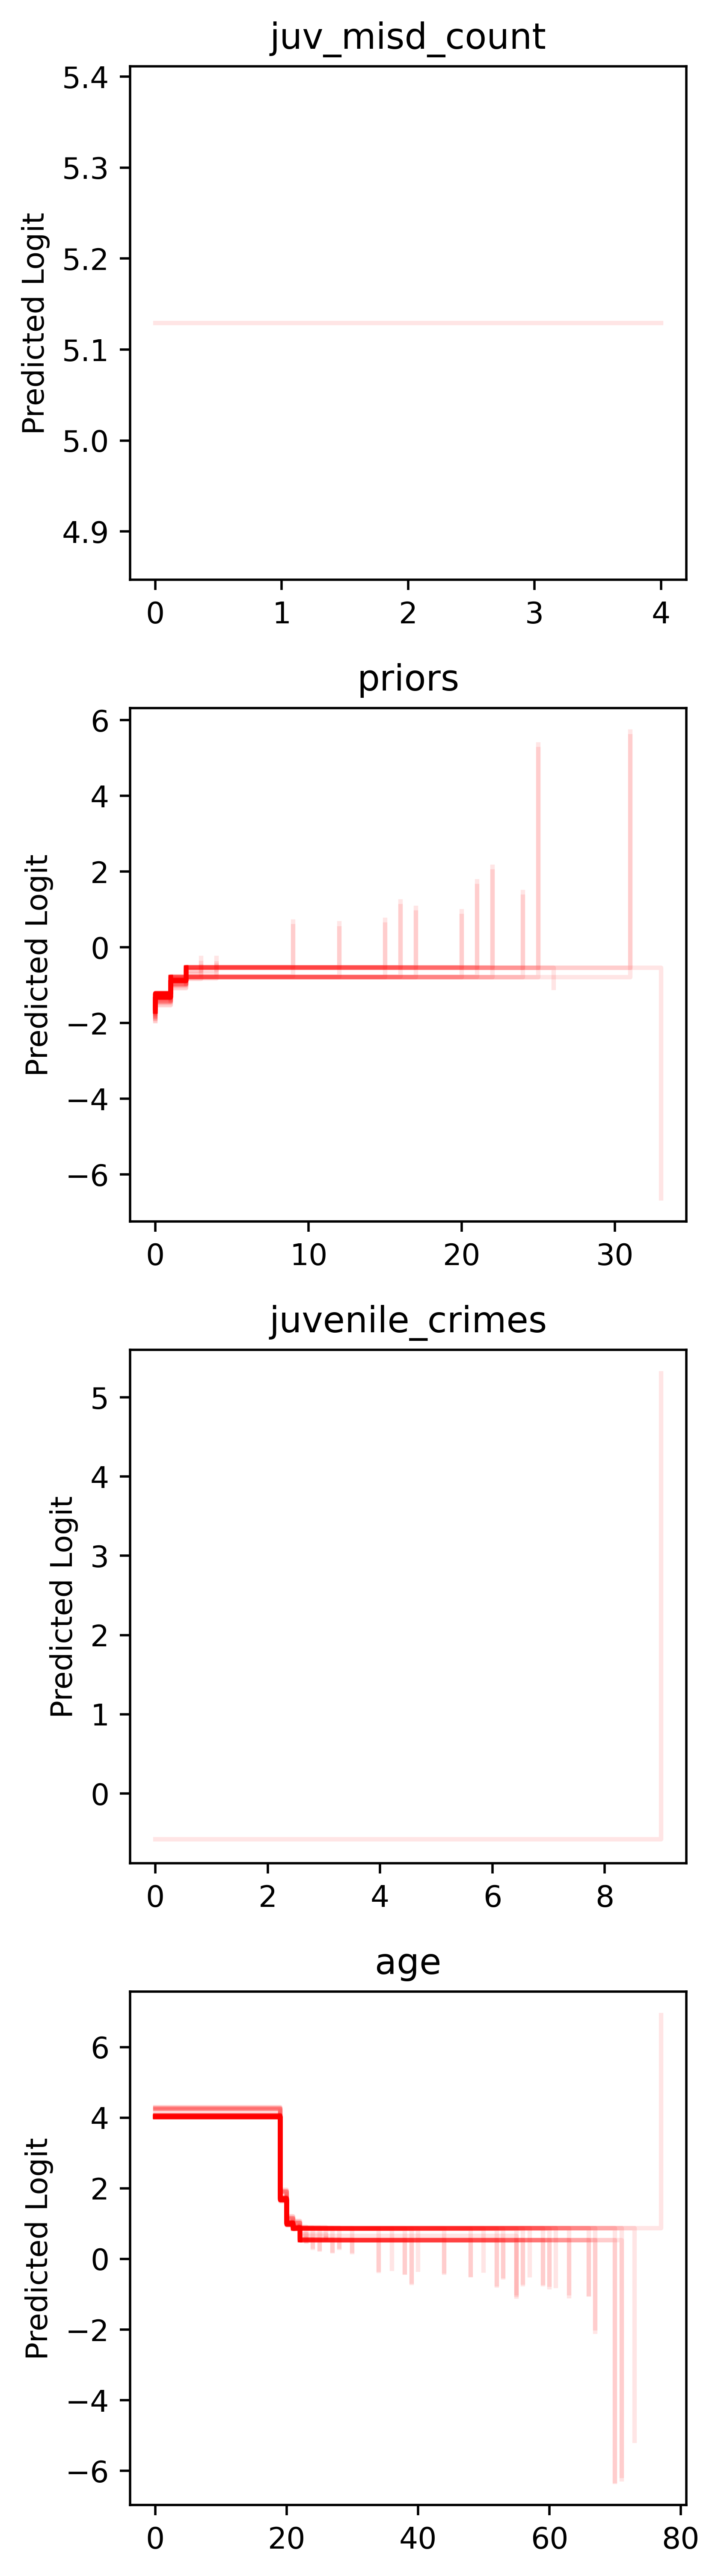

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from tqdm import tqdm

# Input data


def get_feature_thresholds(weights, columns):
    # Extract features and thresholds
    feature_thresholds = {}
    for col, weight in zip(columns, weights):
        match = re.search(r'([a-zA-Z]+)', col)
        if match:
            feature = match.group(1)
            # threshold = col
            threshold = re.findall(r'[\d.]+', col)
            if feature == 'juv':
                feature = 'juv_misd_count'
            if feature == 'juvenile':
                feature = 'juvenile_crimes'
            if feature not in feature_thresholds:
                feature_thresholds[feature] = []
            # if feature == 'current':
            #     print(threshold,list(map(float, threshold)), weight)
            feature_thresholds[feature].append(
                (list(map(float, threshold)), weight))

    return feature_thresholds


def plot_gam(X, X_one_hot, header, list_of_weights):
    # Create subplots
    num_features = X.shape[1]
    # fig, axes = plt.subplots(num_features-2, 1, figsize=(10, 3 * num_features), sharex=False)
    fig = plt.figure(figsize=(13, 3))
    fig.set_dpi(500)
    ax_dict = defaultdict(int)
    if num_features == 1:
        axes = [axes]  # Ensure axes is iterable for a single feature
    counter = 0
    union_of_support_sets = defaultdict(int)
    for i in tqdm(range(len(list_of_weights))):
        weights = list_of_weights[i, :]
        columns = header[np.nonzero(weights)[0]]
        weights = weights[np.nonzero(weights)[0]]
        for column in columns:
            union_of_support_sets[column] += 1

        feature_thresholds = get_feature_thresholds(weights, columns)

        for feature, thresholds_weights in feature_thresholds.items():
            if feature != 'sex' and feature != 'current':
                if feature not in ax_dict:
                    ax = fig.add_axes([0.05, 0.1+counter, 0.2, 0.8])
                    ax_dict[feature] = ax
                    counter += 1
                else:
                    ax = ax_dict[feature]
                thresholds, feature_weights = zip(*thresholds_weights)

                x = range(len(thresholds))  # X-axis positions for thresholds
                x_vals, y_vals = [], []
                x_vals.append(0)
                y_vals.append(feature_weights[0])
                flag = False
                for i in range(len(thresholds) - 1):
                    x_vals.append(thresholds[i][0])
                    y_vals.append(feature_weights[i])
                if flag:
                    continue
                # For the last value of the interval, add it once more

                x_vals.append(thresholds[-1][0])
                y_vals.append(feature_weights[-1])
                # if feature == 'current':
                #     print(feature,thresholds,x_vals, y_vals)
                # x_vals.append(thresholds[-1][0] + 1)  # Extend beyond the last point by 1 (or as needed)
                # y_vals.append(feature_weights[-1])  # Keep the same weight
                ax.step(x_vals, y_vals, where="post", color='r', alpha=0.1)
                ax.set_ylabel("Predicted Logit")
                ax.set_title(feature)
                # ax.legend()
    # plt.xlabel("Thresholds")
    plt.tight_layout()
    plt.show()
    return union_of_support_sets


union_of_support_sets = plot_gam(
    X, X_one_hot, header, sparseDiversePool_betas[:100, :])

In [13]:
mean_loss = 0
for i in range(len(sparseDiversePool_betas)):
    wi = sparseDiversePool_betas[i, :]
    intercepti = sparseDiversePool_beta0[i]
    y_pred = np.exp(X_one_hot@wi + intercepti) / \
        (1+np.exp(X_one_hot@wi + intercepti))
    y_pred[y_pred > 0.5] = 1
    y_pred[y_pred <= 0.5] = -1
    mean_loss += (y != y_pred).mean()
    # print((y!=y_pred).mean())
print(mean_loss/len(sparseDiversePool_betas))

0.33095555233820756


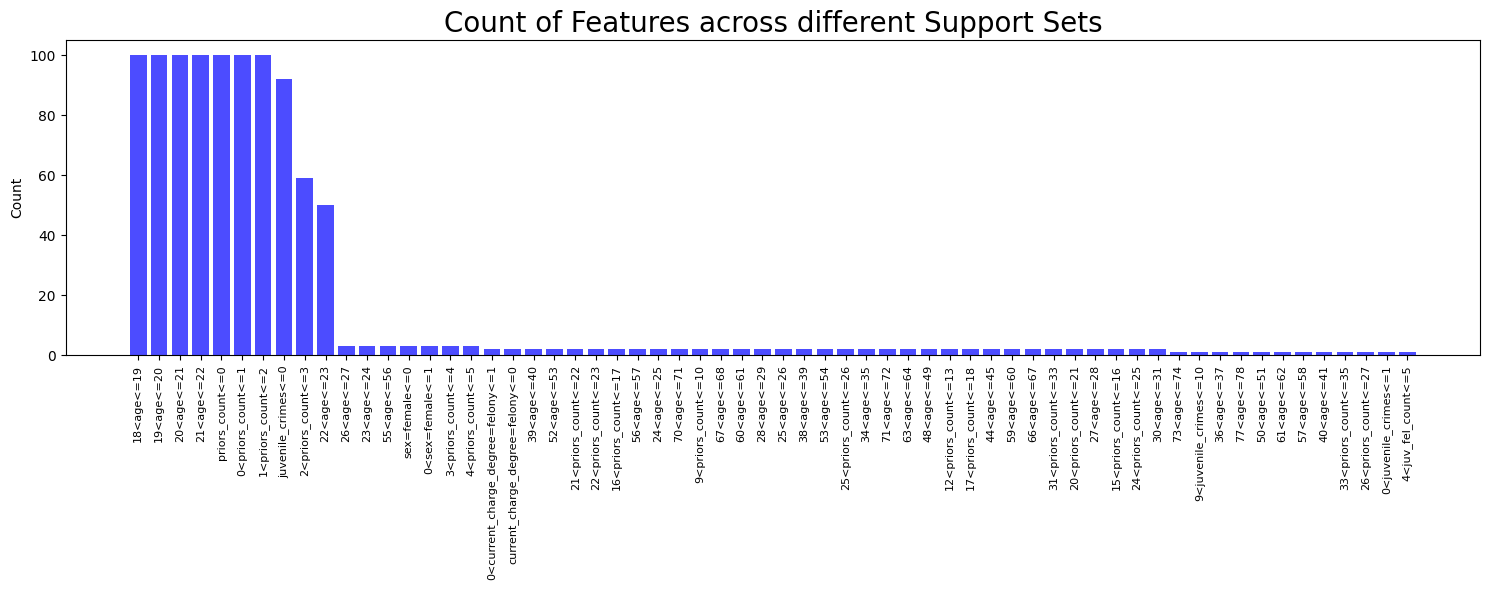

In [14]:
import matplotlib.pyplot as plt
from collections import defaultdict

# Given dictionary
sorted_data = dict(sorted(union_of_support_sets.items(),
                   key=lambda x: x[1], reverse=True))

# Prepare data for histogram
keys = list(sorted_data.keys())
values = list(sorted_data.values())

# # Prepare data for histogram
# keys = list(data.keys())
# values = list(data.values())

# Plot histogram
plt.figure(figsize=(15, 6))
plt.bar(keys, values, color='blue', alpha=0.7)
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('Count')
plt.title('Count of Features across different Support Sets', fontsize=20)
plt.tight_layout()
plt.show()

In [15]:
header = pkl.load(open(betas_fastSparse, 'rb'))['header_new']
header = [i.replace('.0', '') for i in header]
print(keys[:10], header)
# for key in keys[:15]:
#     print(header,key)
# if key in header:
#     print(key)

['18<age<=19', '19<age<=20', '20<age<=21', '21<age<=22', 'priors_count<=0', '0<priors_count<=1', '1<priors_count<=2', 'juvenile_crimes<=0', '2<priors_count<=3', '22<age<=23'] ['intercept', 'age<=22', '22<age<=27', '27<age<=32', '32<age<=33', '33<age<=36', '36<age<=96', 'juvenile_crimes<=0', '0<juvenile_crimes<=20', 'priors_count<=0', '0<priors_count<=1', '1<priors_count<=2', '2<priors_count<=3', '3<priors_count<=4', '4<priors_count<=5', '5<priors_count<=6', '6<priors_count<=7', '7<priors_count<=38']
